In [139]:
import numpy as np
from scipy.integrate import dblquad
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import math
from mpl_toolkits.mplot3d import Axes3D

def gaussian_2d(x, y, x0, y0, sigma):
    """二维高斯函数捏"""
    norm_factor = 1 / (2 * np.pi * sigma * sigma)
    exponent = -1 / 2 * (((x - x0) ** 2 / sigma ** 2) +((y - y0) ** 2 / sigma ** 2))
    return norm_factor * np.exp(exponent)

def fit_pixel_counts(ij, A, x0, y0, sigma, C):
    """输入(i,j)数组，返回对应拟合像素值数组捏"""
    data_fit=[]
    for i, j in ij:
        x_min = i
        x_max = i+1
        y_min = j
        y_max = j+1
        p_pixel, error = dblquad(gaussian_2d, x_min, x_max, lambda y: y_min, lambda y: y_max,
                            args=(x0, y0, sigma))
        data_fit.append(p_pixel*A + C)
    return data_fit

def fit_data(ij, data, average_bg, bg_fit=True, printed=False):
    """用高斯拟合捏"""
    if bg_fit is True:
        initial_guess = [1000, 5.5, 5.5, 1.3, 10] 
        popt, error = curve_fit(fit_pixel_counts, ij, data, p0=initial_guess)
        A_fit, x0_fit, y0_fit, sigma_fit, C_fit = popt
    else:
        initial_guess = [1000, 5.5, 5.5, 1.3] 
        popt, error = curve_fit(lambda ij, A, x0, y0, sigma:fit_pixel_counts(ij, A, x0, y0, sigma, average_bg), ij, data, p0=initial_guess)
        A_fit, x0_fit, y0_fit, sigma_fit = popt
        C_fit = average_bg
    if printed is True:
        print(f"Fitted: {A_fit:.1f}  {x0_fit:.1f}  {y0_fit:.1f}  {sigma_fit:.1f}  {C_fit:.1f}"+'bg_fit='+str(bg_fit))
    return A_fit, x0_fit, y0_fit, sigma_fit, C_fit

def compare_figure(noised_countings, countings_fit):
    """比较生成图和拟合图捏"""
    fig, axs = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)
    vmin = min(noised_countings.min(), countings_fit.min())
    vmax = max(noised_countings.max(), countings_fit.max())
    cax1 = axs[0].imshow(noised_countings, cmap='gray', vmin=vmin, vmax=vmax)
    axs[0].set_title("Pixel Visualization")
    cax2 = axs[1].imshow(countings_fit, cmap='gray', vmin=vmin, vmax=vmax)
    axs[1].set_title("Fitted Pixel Visualization")
    cbar = fig.colorbar(cax1, ax=axs, orientation='vertical')
    cbar.set_label('Countings')
    plt.show()

def pixel_var(noised_countings, countings_fit, length):
    """按像素计算残差方并求平均捏"""
    del_countings = countings_fit - noised_countings
    N_var = []
    x_len = noised_countings.shape[0]
    y_len = noised_countings.shape[1]
    i_range = list(range(length, x_len-length))
    j_range = list(range(length, y_len-length))
    for i in i_range:
        for j in j_range:
            N_var.append(del_countings[i,j] ** 2)
    return sum(N_var)/len(N_var)

class PiexlImage:
    def __init__(self, func, rows, columns, x0, y0, sigma):
        """生成一张空间分布为func的像素图"""
        self.pixel = np.zeros((rows, columns))
        self.func = func
        self.rows = rows
        self.columns = columns
        self.x0 = x0
        self.y0 = y0
        self.sigma = sigma
        self.countings = 0
        self.noise = 0
        self.noise_var = 0
        self.shape = self.pixel.shape
        for i in range(rows):
            for j in range(columns):
                x_min = i
                x_max = i+1
                y_min = j
                y_max = j+1
                p_pixel, error = dblquad(func, x_min, x_max, lambda y: y_min, lambda y: y_max, args=(x0, y0, sigma))
                self.pixel[i,j] = p_pixel
            
    def generate_photons(self, N):
        """生成多项式分布的光子分布"""
        p = self.pixel.flatten()
        pixel = np.random.multinomial(N, p)
        self.pixel = pixel.reshape(self.pixel.shape)
        self.countings = N

    def generate_noise(self, normal_sigma, poisson_lambda):
        """生成高斯和泊松分布"""
        gaussian_noise = np.random.normal(loc=0, scale=normal_sigma, size=self.shape)
        poisson_noise = np.random.poisson(lam=poisson_lambda, size=self.shape)
        bg = gaussian_noise + poisson_noise
        self.pixel = self.pixel + bg
        self.noise += poisson_lambda
        self.noise_var += normal_sigma**2 + poisson_lambda
    
    def add_constant(self, A, C):
        """用于生成拟合的图"""
        self.pixel = self.pixel * A + C

    def show_pixel(self):
        """可视化"""
        fig, ax = plt.subplots(1, 2, figsize=(9, 4.5), constrained_layout=True)
        x = np.arange(self.shape[0])
        y = np.arange(self.shape[1])
        x, y = np.meshgrid(x, y)
        cax1 = ax[0].imshow(self.pixel, cmap='gray')
        ax[0].set_title("2D Visualization")
        ax[0].set_xlabel('X')
        ax[0].set_ylabel('Y')
        fig.colorbar(cax1, ax=ax[0], orientation="vertical")
        ax[1] = fig.add_subplot(122, projection='3d')
        ax[1].set_title("3D Visualization")
        ax[1].plot_surface(x, y, self.pixel, cmap='gray')
        ax[1].set_xlabel('X')
        ax[1].set_ylabel('Y')
        ax[1].set_zlabel('Gray Level')
        plt.show()
        
    def get_fitting_region(self, no_fit_length):
        """输出索引和待拟合矩阵"""
        i_range = list(range(no_fit_length, self.rows - no_fit_length))
        j_range = list(range(no_fit_length, self.columns - no_fit_length))
        ij = []
        data = []
        for i in i_range:
            for j in j_range:
                ij.append((i,j))
                data.append(self.pixel[i,j])
        return ij, data
    
    def get_background(self, bg_averge_length):
        """输出平均背景值"""
        bg = []
        for i in range(self.rows):
            if i not in range(bg_averge_length, self.rows - bg_averge_length):
                for j in range(self.columns):
                    if j not in range(bg_averge_length, self.columns - bg_averge_length):
                        bg.append(self.pixel[i,j])
        return sum(bg)/len(bg)

    def reset(self):
        """重置到分布"""
        self.__init__(self.func, self.rows, self.columns, self.x0, self.y0, self.sigma)

In [140]:
pixel_fig = PiexlImage(gaussian_2d, 13, 13, 6.3, 6.6, 1.25)

In [141]:
pixel_fig.reset()
pixel_fig.generate_photons(400)
pixel_fig.generate_noise(5, 15)

In [142]:
ij, fit_region_value = pixel_fig.get_fitting_region(4)
bg = pixel_fig.get_background(3)

In [143]:
A_fit, x0_fit, y0_fit, sigma_fit, C = fit_data(ij, fit_region_value, bg, bg_fit=False)

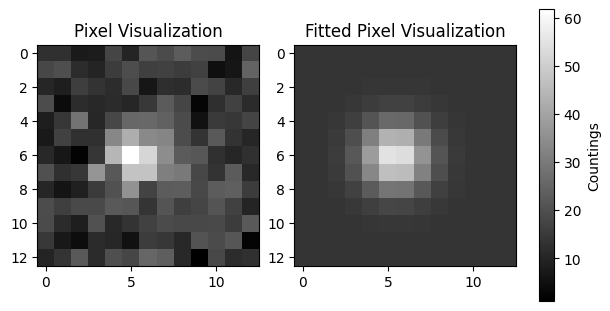

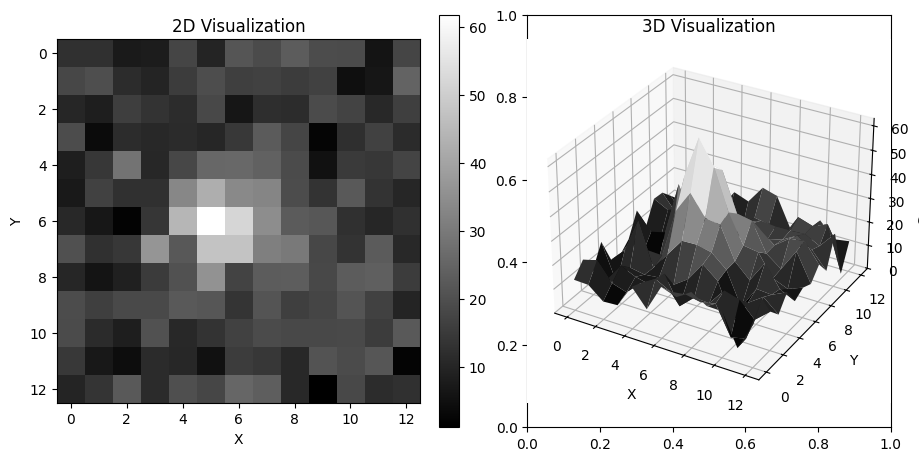

(6.00676413910308,
 501.3521263490518,
 400,
 31.51235818345889,
 5.246145421012696)

In [144]:
fitted_pixel_fig = PiexlImage(gaussian_2d, 13, 13, x0_fit, y0_fit, sigma_fit)
fitted_pixel_fig.add_constant(A_fit, C)
compare_figure(pixel_fig.pixel, fitted_pixel_fig.pixel)
pixel_fig.show_pixel()
averaged_signal = sum(fit_region_value) / len(fit_region_value) # 取2sigma内的单帧亮度平均，以N速率增加
averaged_noise = math.sqrt(pixel_var(pixel_fig.pixel, fitted_pixel_fig.pixel, 4))
SNR = averaged_signal / averaged_noise
SNR, A_fit, pixel_fig.countings, averaged_signal, averaged_noise